In [1]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
img= cv2.imread('./test_images/keanu.jpg')
img.shape

(900, 1200, 3)

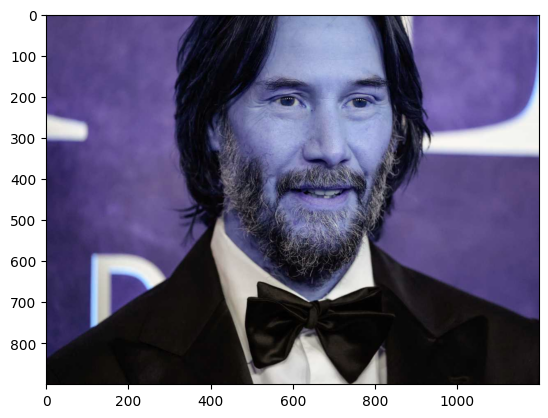

In [3]:
plt.imshow(img)

In [4]:
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray.shape

(900, 1200)

In [5]:
gray

array([[ 80,  80,  79, ..., 141, 162, 175],
       [ 80,  80,  79, ..., 141, 162, 175],
       [ 81,  80,  80, ..., 141, 162, 175],
       ...,
       [  8,   8,   8, ...,   8,   5,   3],
       [  8,   8,   8, ...,   8,   5,   3],
       [  8,   8,   8, ...,   8,   5,   3]],
      shape=(900, 1200), dtype=uint8)

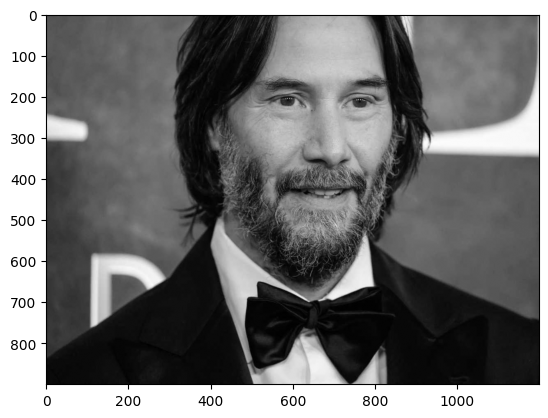

In [6]:
plt.imshow(gray,cmap='gray')

In [7]:
face_cascade= cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade= cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_eye.xml')

faces=face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[461,  41, 450, 450]], dtype=int32)

In [8]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(461), np.int32(41), np.int32(450), np.int32(450))

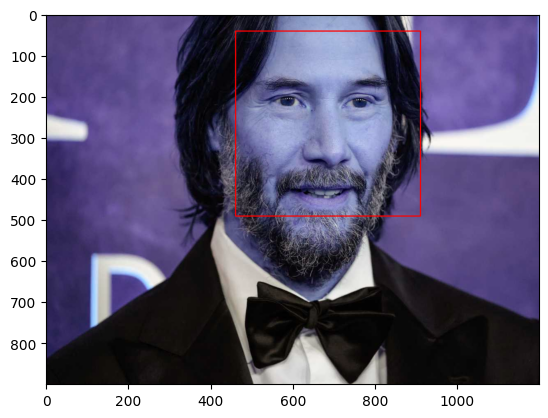

In [9]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

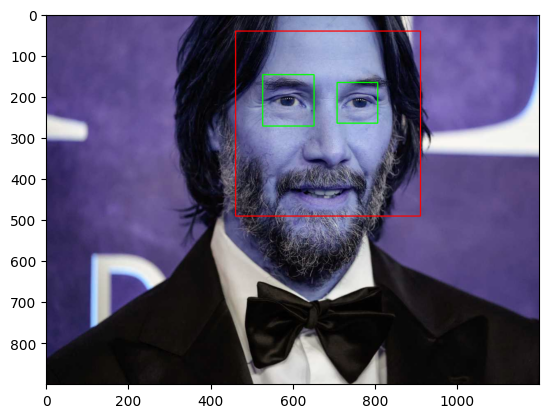

In [10]:
cv2.destroyAllWindows()
#for (x,y,w,h) in faces:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
roi_gray = gray[y:y+h,x:x+h]
roi_color = face_img[y:y+h, x:x+w]
eyes = eye_cascade.detectMultiScale(roi_gray)
for(ex,ey,ew,eh) in eyes:
    cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

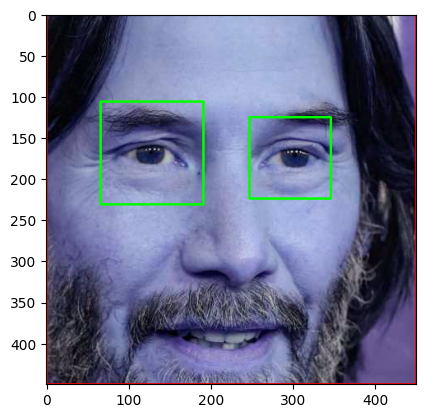

In [11]:
%matplotlib inline
plt.imshow(roi_color, cmap='gray')

In [12]:
#FUNCTION TO CHECK IF 2 EYES VISIBLE
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"WARNING: Could not read image file '{image_path}'. Skipping this file.")
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >=2:
            return roi_color

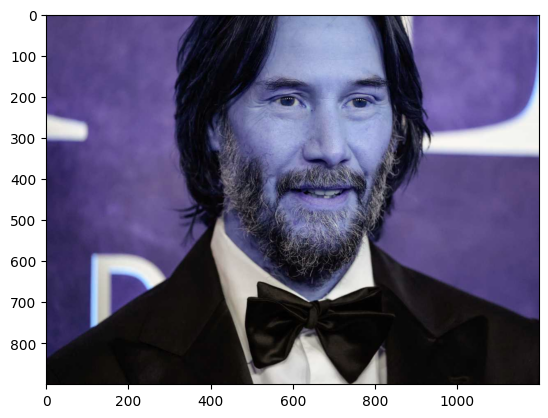

In [13]:
original_image= cv2.imread('./test_images/keanu.jpg')
plt.imshow(original_image)

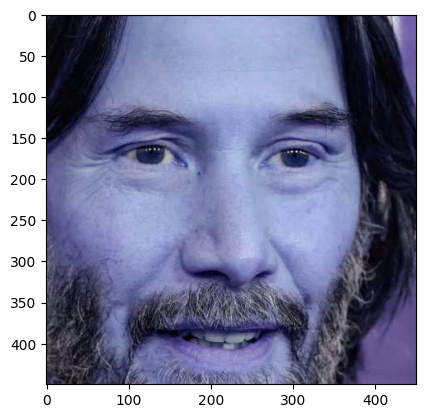

In [14]:
cropped_image = get_cropped_image_if_2_eyes('./test_images/keanu.jpg')
plt.imshow(cropped_image)

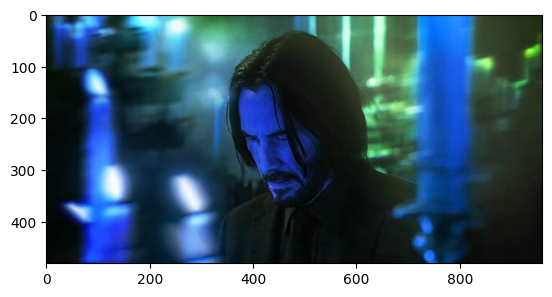

In [15]:
img_obstructed = cv2.imread('./test_images/keanu_2.jpg')
plt.imshow(img_obstructed)

In [16]:
cropped_image_no_2_eyes = get_cropped_image_if_2_eyes('./test_images/keanu_2.jpg')
cropped_image_no_2_eyes

In [17]:
path_to_data='./dataset/'
path_to_cr_data='./dataset/cropped/'

In [18]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [19]:
img_dirs

['./dataset/cropped',
 './dataset/Emma_Watson',
 './dataset/Leonardo_DiCaprio',
 './dataset/Robert_Downey_Jr',
 './dataset/Scarlett_Johansson',
 './dataset/Tom_Cruise']

In [20]:
import shutil
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [21]:
cropped_image_dirs=[]
celebrity_file_names_dict={}

In [22]:
for img_dir in img_dirs:
    count = 1
    celebrity_name=img_dir.split('/')[-1]
    print(celebrity_name)
    
    celebrity_file_names_dict[celebrity_name]=[]
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print('Generating cropped images in folder:',cropped_folder)
                
            cropped_file_name = celebrity_name + str(count) + '.png'
            cropped_file_path = cropped_folder + '/' + cropped_file_name

            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count+=1
            

cropped
Emma_Watson
Generating cropped images in folder: ./dataset/cropped/Emma_Watson
Leonardo_DiCaprio
Generating cropped images in folder: ./dataset/cropped/Leonardo_DiCaprio
Robert_Downey_Jr
Generating cropped images in folder: ./dataset/cropped/Robert_Downey_Jr
Scarlett_Johansson
Generating cropped images in folder: ./dataset/cropped/Scarlett_Johansson
Tom_Cruise
Generating cropped images in folder: ./dataset/cropped/Tom_Cruise


In [23]:
import pywt

def w2d(img, mode='haar', level=1):
    imArray = img
    imArray = cv2.cvtColor( imArray, cv2.COLOR_RGB2GRAY)
    imArray = np.float32(imArray)
    imArray /= 255;
    coeffs = pywt.wavedec2(imArray, mode, level=level)
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0;

    imArray_H = pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H = np.uint8(imArray_H)

    return imArray_H    

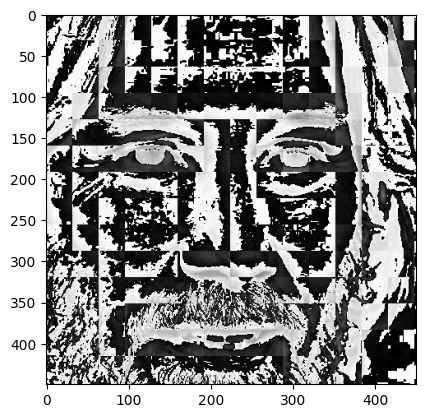

In [24]:
im_har = w2d(cropped_image,'db1',5)
plt.imshow(im_har, cmap = 'gray')

In [25]:
celebrity_file_names_dict

{'cropped': [],
 'Emma_Watson': ['./dataset/cropped/Emma_Watson/Emma_Watson1.png',
  './dataset/cropped/Emma_Watson/Emma_Watson2.png',
  './dataset/cropped/Emma_Watson/Emma_Watson3.png',
  './dataset/cropped/Emma_Watson/Emma_Watson4.png',
  './dataset/cropped/Emma_Watson/Emma_Watson5.png',
  './dataset/cropped/Emma_Watson/Emma_Watson6.png',
  './dataset/cropped/Emma_Watson/Emma_Watson7.png',
  './dataset/cropped/Emma_Watson/Emma_Watson8.png',
  './dataset/cropped/Emma_Watson/Emma_Watson9.png',
  './dataset/cropped/Emma_Watson/Emma_Watson10.png',
  './dataset/cropped/Emma_Watson/Emma_Watson11.png',
  './dataset/cropped/Emma_Watson/Emma_Watson12.png',
  './dataset/cropped/Emma_Watson/Emma_Watson13.png',
  './dataset/cropped/Emma_Watson/Emma_Watson14.png',
  './dataset/cropped/Emma_Watson/Emma_Watson15.png',
  './dataset/cropped/Emma_Watson/Emma_Watson16.png',
  './dataset/cropped/Emma_Watson/Emma_Watson17.png',
  './dataset/cropped/Emma_Watson/Emma_Watson18.png',
  './dataset/cropped/Emm

In [26]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
        class_dict[celebrity_name] = count
        count += 1
class_dict

{'cropped': 0,
 'Emma_Watson': 1,
 'Leonardo_DiCaprio': 2,
 'Robert_Downey_Jr': 3,
 'Scarlett_Johansson': 4,
 'Tom_Cruise': 5}

In [27]:
X, y =[], []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue
        scaled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img,'db1',5)
        scaled_img_har = cv2.resize(img_har,(32,32))
        combined_img = np.vstack((scaled_raw_img.reshape(32*32*3,1),scaled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])

In [28]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(282, 4096)

In [29]:
X[0]

array([167., 164., 166., ..., 241.,   1., 242.], shape=(4096,))

In [30]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [31]:
X_train, X_test, y_train, y_test = train_test_split( X, y, random_state=0)
pipe = Pipeline([('scaler', StandardScaler()),('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, y_train)
pipe.score(X_test,y_test) 

0.6619718309859155

In [32]:
len(X_test)

71

In [33]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           1       0.62      0.67      0.65        15
           2       0.47      0.70      0.56        10
           3       0.60      0.46      0.52        13
           4       0.75      0.83      0.79        18
           5       0.90      0.60      0.72        15

    accuracy                           0.66        71
   macro avg       0.67      0.65      0.65        71
weighted avg       0.69      0.66      0.66        71



In [34]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [35]:
model_params={
    'svm':{
        'model': svm.SVC(gamma='auto',probability=True),
        'params' :{
            'svc__C': [1,10,100,1000],
            'svc__kernel':['rbf','linear']
        }
    },
    'random_forest':{
        'model': RandomForestClassifier(),
        'params':{
            'randomforestclassifier__n_estimators':[1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='liblinear',multi_class='auto'),
        'params':{
        'logisticregression__C':[1,5,10]
        }
    }
}
        

In [36]:
scores=[]
best_estimators={}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf = GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
    'model': algo,
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_

df = pd.DataFrame(scores, columns=['model','best_score','best_params'])
df

E:\New folder (2)\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
E:\New folder (2)\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
E:\New folder (2)\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
E:\New folder (2)\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

,model,best_score,best_params
0,svm,0.696899,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.445736,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.725249,{'logisticregression__C': 1}


In [37]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc',
                  SVC(C=1, gamma='auto', kernel='linear', probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=10))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=1, multi_class='auto',
                                     solver='liblinear'))])}

In [38]:
best_estimators['svm'].score(X_test,y_test)

0.7183098591549296

In [39]:
best_estimators['random_forest'].score(X_test,y_test)

0.4788732394366197

In [40]:
best_estimators['logistic_regression'].score(X_test,y_test)

0.7605633802816901

In [41]:
best_clf=best_estimators['svm']

In [42]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[13,  1,  1,  0,  0],
       [ 0,  8,  0,  2,  0],
       [ 2,  0,  7,  1,  3],
       [ 0,  3,  1, 14,  0],
       [ 1,  3,  1,  1,  9]])

Text(95.72222222222221, 0.5, 'Truth')

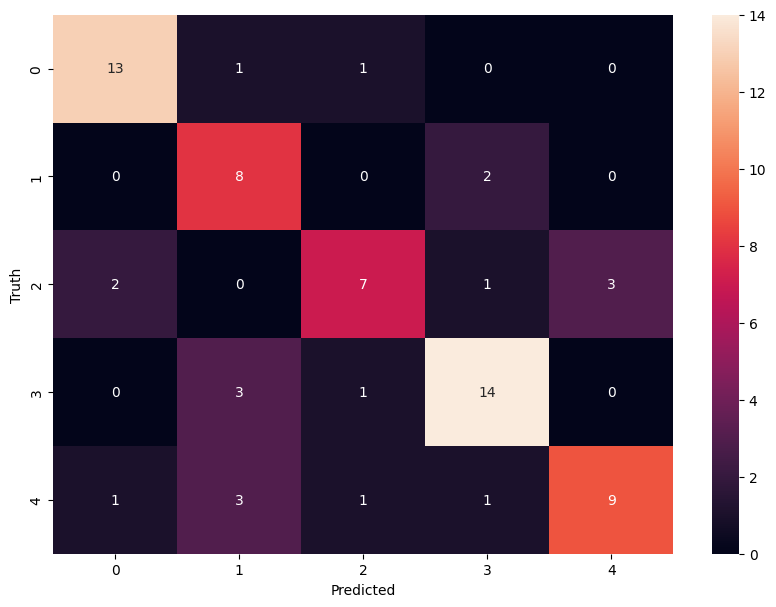

In [43]:
import seaborn as sns
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [44]:
class_dict

{'cropped': 0,
 'Emma_Watson': 1,
 'Leonardo_DiCaprio': 2,
 'Robert_Downey_Jr': 3,
 'Scarlett_Johansson': 4,
 'Tom_Cruise': 5}

In [45]:
!pip install joblib
import joblib

In [48]:
joblib.dump(best_clf,'save_model.pkl')

['save_model.pkl']

In [49]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))